In [1]:
import numpy as np
import pandas as pd 
import re
import os
os.chdir('..')  # Go up to project root
import plotly.express as px
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from scipy import stats
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/broad-peak.csv
./kaggle/input/lhotse.csv
./kaggle/input/kangchenjunga.csv
./kaggle/input/.DS_Store
./kaggle/input/cho-oyu.csv
./kaggle/input/everest_20-25.csv
./kaggle/input/manaslu.csv
./kaggle/input/dhaulagiri-I.csv
./kaggle/input/everest.csv
./kaggle/input/k2.csv
./kaggle/input/nanga-parbat.csv
./kaggle/input/Mount Everest Accident Dataset 2020-2025.csv
./kaggle/input/gasherbrum-II.csv
./kaggle/input/shishapangma.csv
./kaggle/input/gasherbrum-I.csv
./kaggle/input/annapurna-I.csv
./kaggle/input/makalu.csv


In [2]:
broadpeek = pd.read_csv('./kaggle/input/broad-peak.csv')
lhotse = pd.read_csv('./kaggle/input/lhotse.csv')
kangchenjunga = pd.read_csv('./kaggle/input/kangchenjunga.csv')
chooyu = pd.read_csv('./kaggle/input/cho-oyu.csv')
manaslu = pd.read_csv('./kaggle/input/manaslu.csv')
dhaulagiri = pd.read_csv('./kaggle/input/dhaulagiri-I.csv')
everest = pd.read_csv('./kaggle/input/everest.csv')
k2 = pd.read_csv('./kaggle/input/k2.csv')
nangaparbat = pd.read_csv('./kaggle/input/nanga-parbat.csv')
gasherbrum2 = pd.read_csv('./kaggle/input/gasherbrum-II.csv')
gasherbrum1 = pd.read_csv('./kaggle/input/gasherbrum-I.csv')
shishapangma = pd.read_csv('./kaggle/input/shishapangma.csv')
annapurna1 = pd.read_csv('./kaggle/input/annapurna-I.csv')
makalu = pd.read_csv('./kaggle/input/makalu.csv')

In [3]:
# Assign mountain in each dataset
broadpeek['mountain'] = 'Broad Peak'
lhotse['mountain'] = 'Lhotse'
kangchenjunga['mountain'] = 'Kangchenjunga'
chooyu['mountain'] = 'Chooyu'
manaslu['mountain'] = 'Manaslu'
dhaulagiri['mountain'] = 'Dhaulagiri I'
everest['mountain'] = 'Everest'
k2['mountain'] = 'K2'
nangaparbat['mountain'] = 'Nanga Parbat'
gasherbrum1['mountain'] = 'Gasherbrum I'
gasherbrum2['mountain'] = 'Gasherbrum II'
makalu['mountain'] = 'Makalu'
annapurna1['mountain'] = 'Annapurna I'
shishapangma['mountain'] = 'Shishapangma'

# Join datasets
allmountains = pd.concat([
    broadpeek, lhotse, kangchenjunga, chooyu, manaslu, dhaulagiri,
    everest, k2, nangaparbat, gasherbrum2, gasherbrum1, 
    shishapangma, annapurna1, makalu
], ignore_index=True)

In [4]:
# Format dates
allmountains['Date'] = pd.to_datetime(allmountains['Date'], format='mixed', errors='coerce')
allmountains['year'] = allmountains['Date'].dt.year
allmountains['month'] = allmountains['Date'].dt.month

# Check if any dates failed to parse
print(f"Missing dates: {allmountains['Date'].isna().sum()}")

# Deaths per year
allmountains['year'].value_counts().sort_index()

Missing dates: 0


year
1895     3
1905     3
1922     7
1924     4
1929     1
        ..
2017     9
2018    16
2019    25
2021    12
2022     4
Name: count, Length: 76, dtype: int64

In [5]:
# Format latitude and longitude to be uniform
def parse_coordinates(coord_str):
    if pd.isna(coord_str):
        return None, None
    
    # Handle format like "35°52′57″N 76°30′48″E"
    if '″' in coord_str or '′' in coord_str:
        # Extract numbers for latitude
        lat_match = re.search(r'(\d+)°(\d+)′(\d+)″([NS])', coord_str)
        lon_match = re.search(r'(\d+)°(\d+)′(\d+)″([EW])', coord_str)
        
        if lat_match and lon_match:
            # Convert DMS to decimal degrees
            lat_deg, lat_min, lat_sec, lat_dir = lat_match.groups()
            lon_deg, lon_min, lon_sec, lon_dir = lon_match.groups()
            
            lat = float(lat_deg) + float(lat_min)/60 + float(lat_sec)/3600
            lon = float(lon_deg) + float(lon_min)/60 + float(lon_sec)/3600
            
            # Handle South/West as negative
            if lat_dir == 'S':
                lat = -lat
            if lon_dir == 'W':
                lon = -lon
                
            return lat, lon
    
    # Handle format like "35.8107° N, 76.5680° E"
    elif '°' in coord_str:
        parts = coord_str.split(',')
        lat = float(parts[0].replace('° N', '').replace('° S', '').replace('°', '').strip())
        lon = float(parts[1].replace('° E', '').replace('° W', '').replace('°', '').strip())
        
        if 'S' in parts[0]:
            lat = -lat
        if 'W' in parts[1]:
            lon = -lon
            
        return lat, lon
    
    return None, None

# Apply the function
allmountains['lat'], allmountains['lon'] = zip(*allmountains['Lat, Lon'].apply(parse_coordinates))

# Check if it worked
print("Sample coordinates:")
print(allmountains[['mountain', 'Lat, Lon', 'lat', 'lon']].drop_duplicates('mountain').head(10))

Sample coordinates:
          mountain                Lat, Lon        lat        lon
0       Broad Peak  35.8107° N, 76.5680° E  35.810700  76.568000
35          Lhotse  27.9626° N, 86.9336° E  27.962600  86.933600
66   Kangchenjunga  27.7025° N, 88.1475° E  27.702500  88.147500
123         Chooyu  28.0960° N, 86.6615° E  28.096000  86.661500
175        Manaslu  28.5497° N, 84.5597° E  28.549700  84.559700
261   Dhaulagiri I  28.6985° N, 83.4873° E  28.698500  83.487300
344        Everest  27.9882° N, 86.9254° E  27.988200  86.925400
655             K2  35.8800° N, 76.5151° E  35.880000  76.515100
747   Nanga Parbat  35.2375° N, 74.5891° E  35.237500  74.589100
832  Gasherbrum II   35°45′30″N 76°39′12″E  35.758333  76.653333


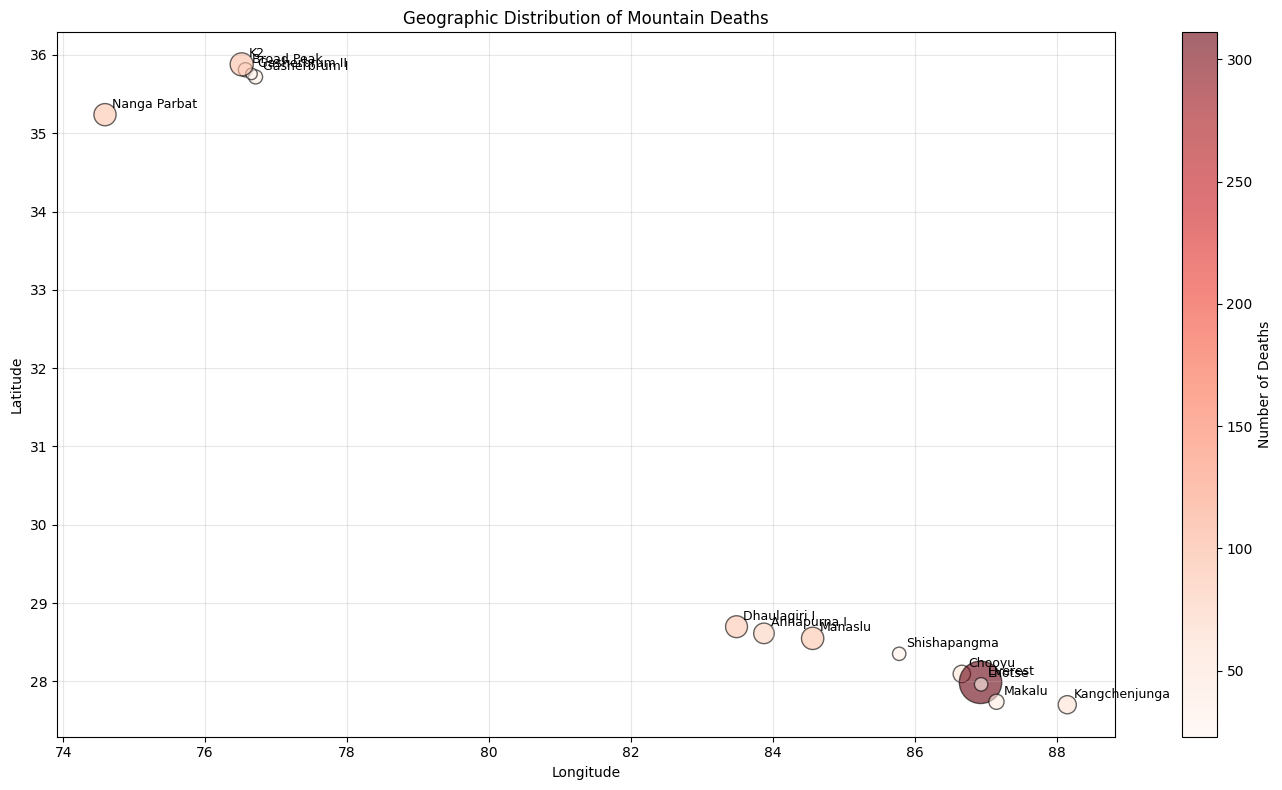

Mountain Locations and Death Counts:
         mountain        lat        lon  deaths
4         Everest  27.988200  86.925400     311
7              K2  35.880000  76.515100      92
11        Manaslu  28.549700  84.559700      86
12   Nanga Parbat  35.237500  74.589100      85
3    Dhaulagiri I  28.698500  83.487300      83
0     Annapurna I  28.613600  83.873600      73
8   Kangchenjunga  27.702500  88.147500      57
2          Chooyu  28.096000  86.661500      52
10         Makalu  27.740000  87.150000      40
1      Broad Peak  35.810700  76.568000      35
5    Gasherbrum I  35.719300  76.710600      34
9          Lhotse  27.962600  86.933600      31
13   Shishapangma  28.352500  85.779200      31
6   Gasherbrum II  35.758333  76.653333      23


In [6]:
# Get unique mountains with their coordinates and death counts
mountain_stats = allmountains.groupby(['mountain', 'lat', 'lon']).size().reset_index(name='deaths')

# Create scatter plot
plt.figure(figsize=(14, 8))
plt.scatter(mountain_stats['lon'], mountain_stats['lat'], 
            s=mountain_stats['deaths']*3,  # Size by death count
            c=mountain_stats['deaths'],     # Color by death count
            cmap='Reds', 
            alpha=0.6, 
            edgecolors='black',
            linewidth=1)

# Add mountain labels
for idx, row in mountain_stats.iterrows():
    plt.annotate(row['mountain'], 
                 (row['lon'], row['lat']),
                 fontsize=9,
                 xytext=(5, 5),
                 textcoords='offset points')

plt.colorbar(label='Number of Deaths')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Mountain Deaths')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/mountain_deaths_map.png', dpi=300, bbox_inches='tight')
plt.show()

print("Mountain Locations and Death Counts:")
print(mountain_stats.sort_values('deaths', ascending=False))

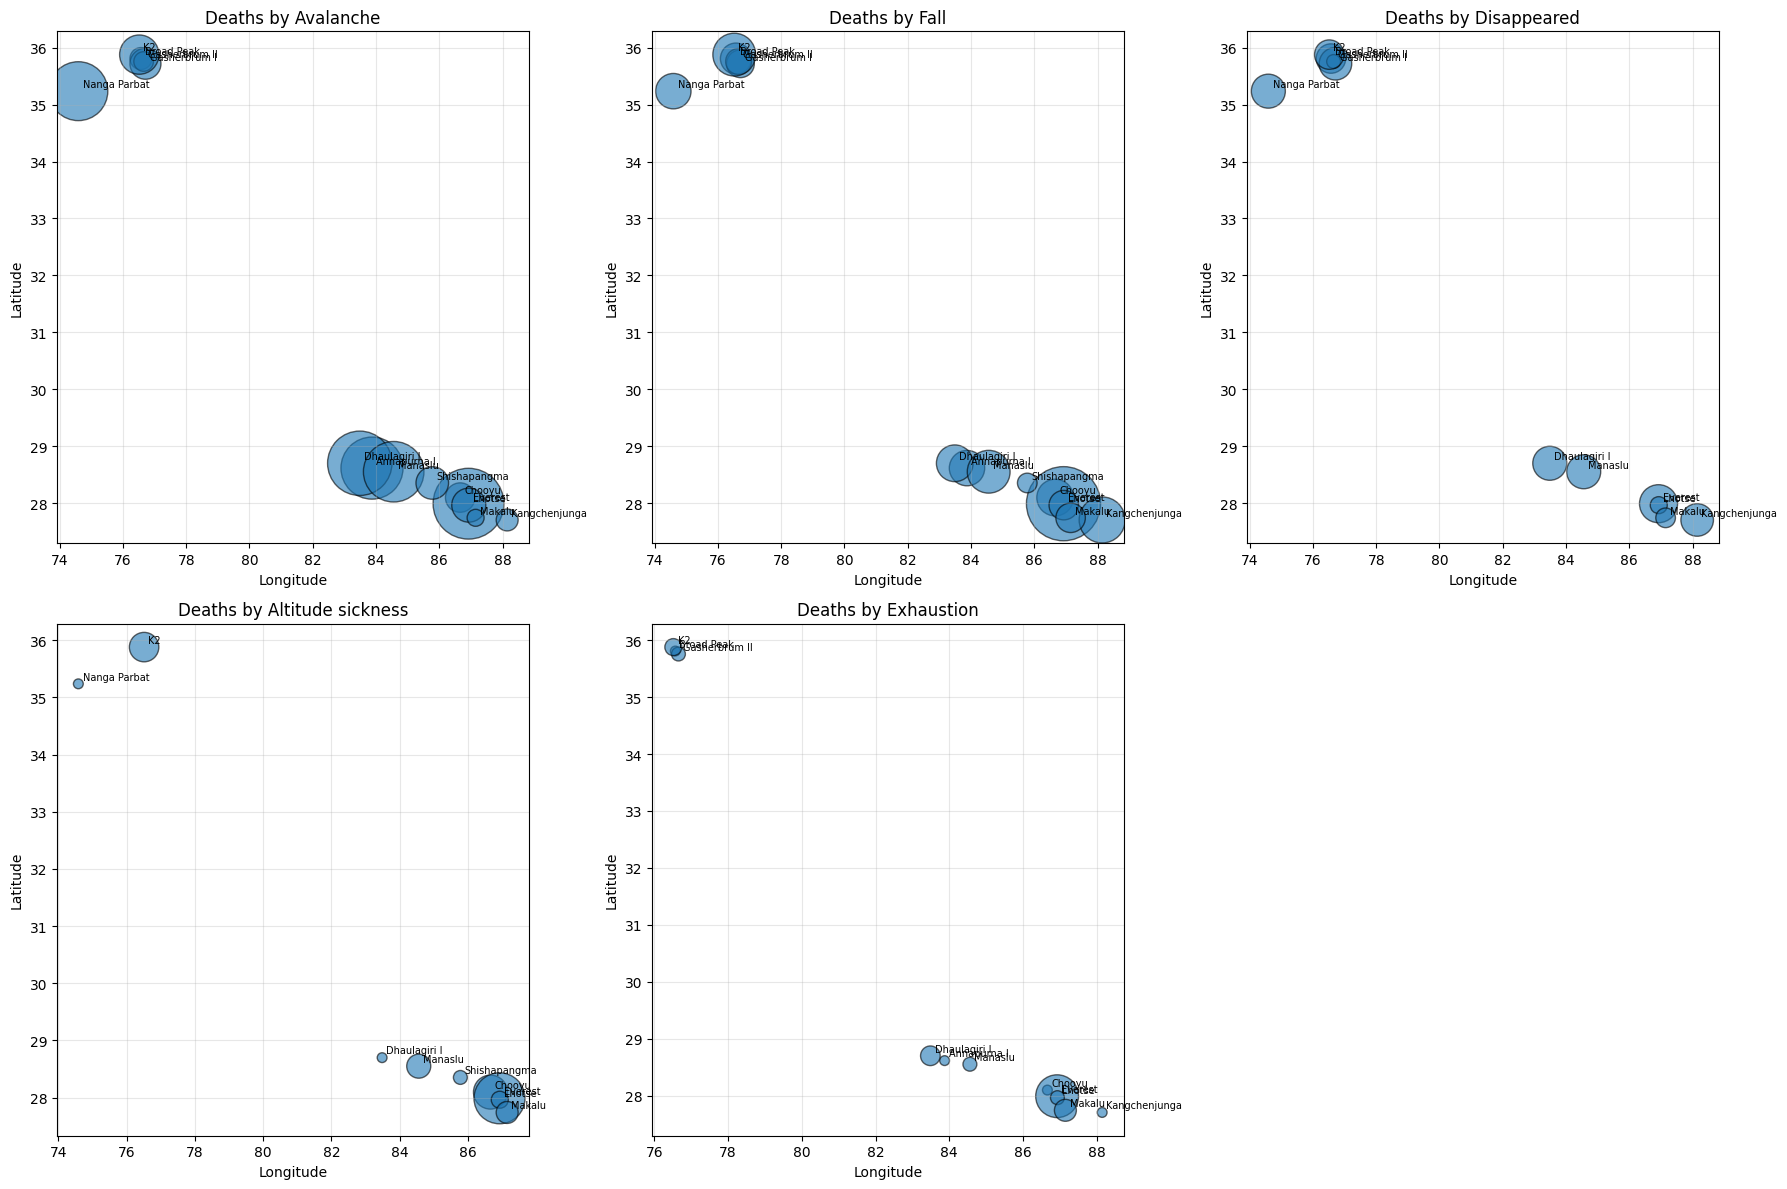

In [7]:
# Deaths by cause for each mountain
cause_by_mountain = allmountains.groupby(['mountain', 'lat', 'lon', 'Cause of death']).size().reset_index(name='count')
top_causes = allmountains['Cause of death'].value_counts().head(5).index

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, cause in enumerate(top_causes):
    ax = axes[idx]
    cause_data = cause_by_mountain[cause_by_mountain['Cause of death'] == cause]
    
    ax.scatter(cause_data['lon'], cause_data['lat'], 
               s=cause_data['count']*50,
               alpha=0.6,
               edgecolors='black')
    
    for _, row in cause_data.iterrows():
        ax.annotate(row['mountain'], 
                   (row['lon'], row['lat']),
                   fontsize=7,
                   xytext=(3, 3),
                   textcoords='offset points')
    
    ax.set_title(f'Deaths by {cause}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('images/deaths_by_cause_geography.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Create base map centered on the Himalayas
map_center = [28.0, 84.0]
m = folium.Map(location=map_center, zoom_start=6)

# Add markers for each mountain
for _, row in mountain_stats.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['deaths']/10,  # Scale circle size
        popup=f"{row['mountain']}<br>{row['deaths']} deaths",
        color='red',
        fill=True,
        fillColor='red',
        fillOpacity=0.6
    ).add_to(m)

# Save as HTML
m.save('mountain_deaths_interactive_map.html')
print("Interactive map saved as 'mountain_deaths_interactive_map.html'")

Interactive map saved as 'mountain_deaths_interactive_map.html'


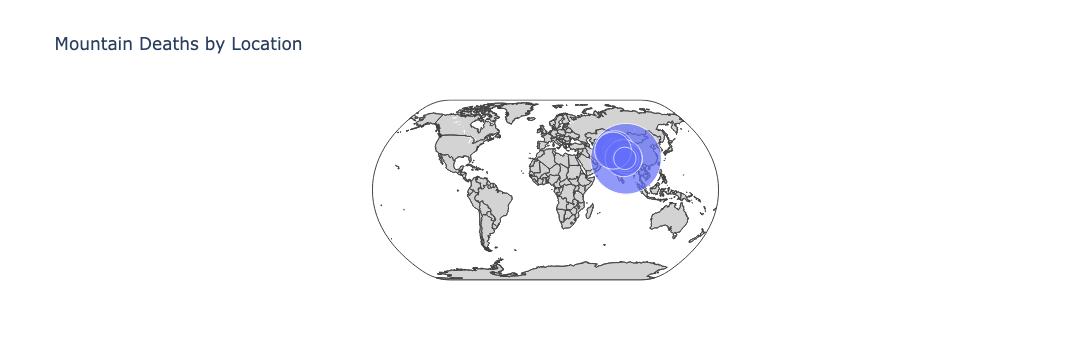

In [9]:
# Get unique mountains with their coordinates and death counts
mountain_stats = allmountains.groupby(['mountain', 'lat', 'lon']).size().reset_index(name='deaths')

fig = px.scatter_geo(mountain_stats,
                     lat='lat',
                     lon='lon',
                     size='deaths',
                     hover_name='mountain',
                     hover_data={'deaths': True, 'lat': False, 'lon': False},
                     title='Mountain Deaths by Location',
                     projection='natural earth',
                     size_max=50)

fig.update_geos(showcountries=True, showcoastlines=True, showland=True, landcolor='lightgray')
fig.write_html('mountain_deaths_world_map.html')
fig.show()

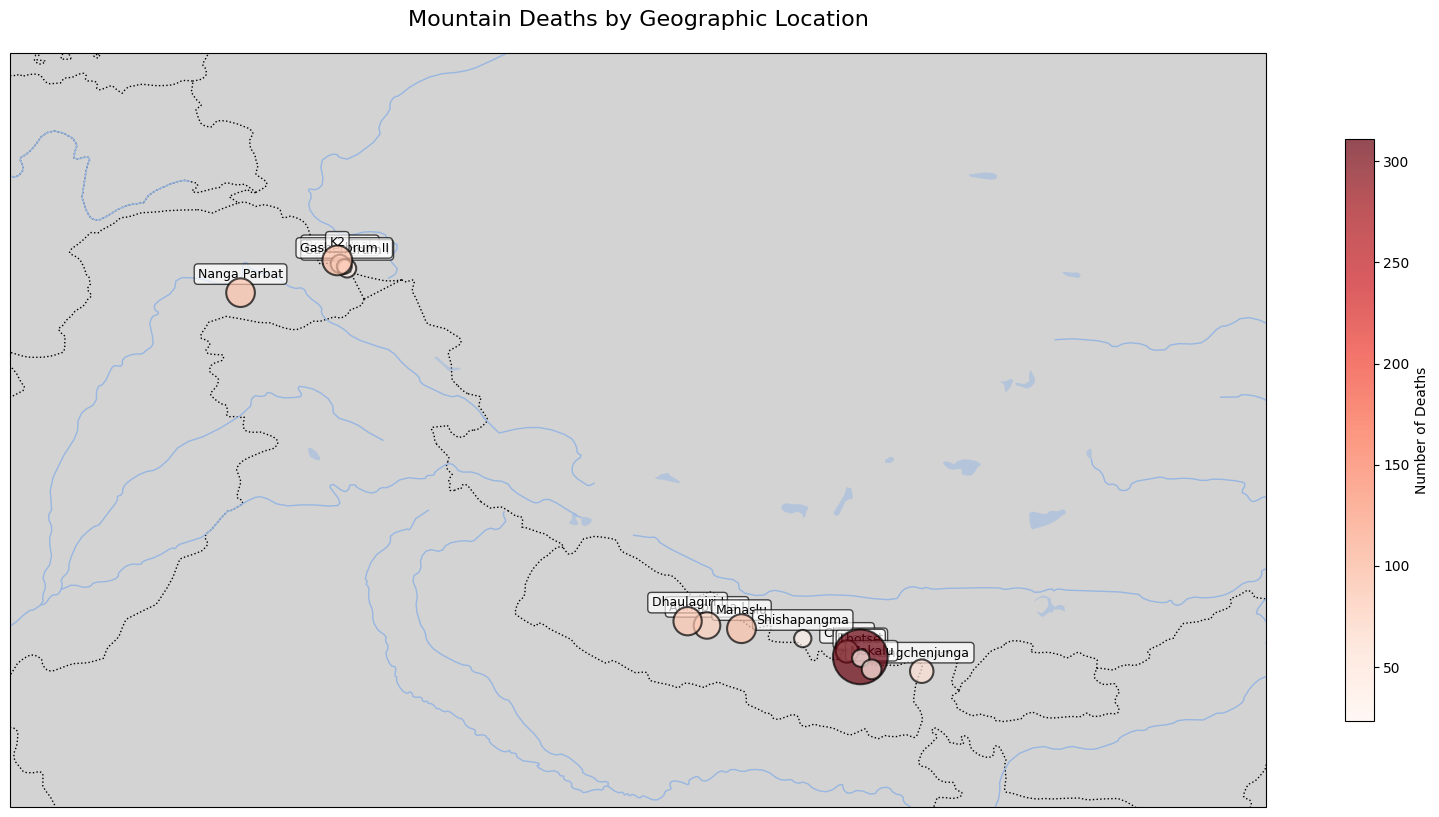

In [10]:
# Get mountain stats
mountain_stats = allmountains.groupby(['mountain', 'lat', 'lon']).size().reset_index(name='deaths')

# Create map
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Set extent to focus on Himalayas region
ax.set_extent([70, 95, 25, 40], crs=ccrs.PlateCarree())

# Plot mountains
scatter = ax.scatter(mountain_stats['lon'], mountain_stats['lat'],
                     s=mountain_stats['deaths']*5,
                     c=mountain_stats['deaths'],
                     cmap='Reds',
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=1.5,
                     transform=ccrs.PlateCarree(),
                     zorder=5)

# Add labels
for _, row in mountain_stats.iterrows():
    ax.text(row['lon'], row['lat']+0.3, row['mountain'],
            fontsize=9,
            ha='center',
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.colorbar(scatter, ax=ax, label='Number of Deaths', shrink=0.6)
plt.title('Mountain Deaths by Geographic Location', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('images/mountain_deaths_world_map.png', dpi=300, bbox_inches='tight')
plt.show()

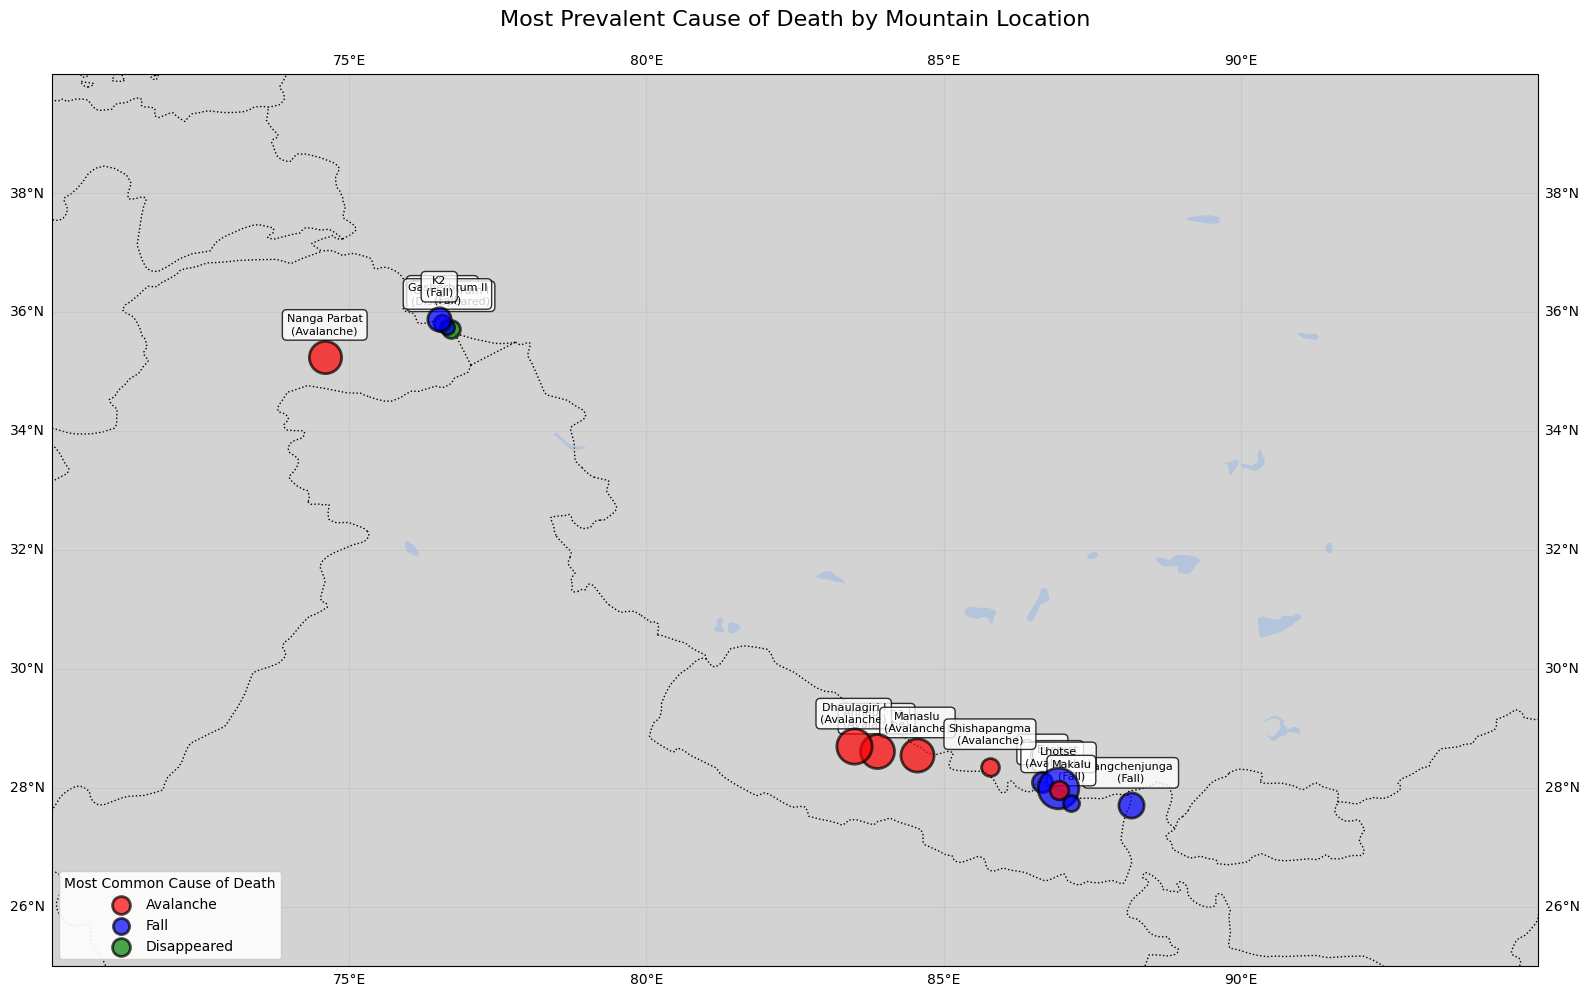


Most Common Cause of Death by Mountain:
Everest              - Fall                 (57 deaths)
Dhaulagiri I         - Avalanche            (43 deaths)
Annapurna I          - Avalanche            (40 deaths)
Manaslu              - Avalanche            (38 deaths)
Nanga Parbat         - Avalanche            (36 deaths)
Kangchenjunga        - Fall                 (22 deaths)
K2                   - Fall                 (19 deaths)
Chooyu               - Fall                 (14 deaths)
Lhotse               - Avalanche            (12 deaths)
Gasherbrum I         - Disappeared          (11 deaths)
Shishapangma         - Avalanche            (11 deaths)
Broad Peak           - Fall                 (10 deaths)
Makalu               - Fall                 (9 deaths)
Gasherbrum II        - Fall                 (7 deaths)


In [11]:
# Get top causes of death
top_causes = allmountains['Cause of death'].value_counts().head(5).index

# Filter to top causes and get stats by mountain/location
cause_data = allmountains[allmountains['Cause of death'].isin(top_causes)]
cause_stats = cause_data.groupby(['mountain', 'lat', 'lon', 'Cause of death']).size().reset_index(name='count')

# Find most common cause for each mountain
most_common = cause_stats.loc[cause_stats.groupby('mountain')['count'].idxmax()]

# Create color map for causes
colors = {
    top_causes[0]: 'red',
    top_causes[1]: 'blue', 
    top_causes[2]: 'green',
    top_causes[3]: 'orange',
    top_causes[4]: 'purple'
}

# Create map
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Set extent to focus on Himalayas/Karakoram region
ax.set_extent([70, 95, 25, 40], crs=ccrs.PlateCarree())

# Plot each mountain colored by most common cause of death
for _, row in most_common.iterrows():
    ax.scatter(row['lon'], row['lat'],
               s=row['count']*15,
               c=colors.get(row['Cause of death'], 'gray'),
               alpha=0.7,
               edgecolors='black',
               linewidth=2,
               transform=ccrs.PlateCarree(),
               zorder=5,
               label=row['Cause of death'])

# Add mountain labels
for _, row in most_common.iterrows():
    ax.text(row['lon'], row['lat']+0.4, 
            f"{row['mountain']}\n({row['Cause of death']})",
            fontsize=8,
            ha='center',
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# Create legend (remove duplicates)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), 
          title='Most Common Cause of Death',
          loc='lower left',
          fontsize=10,
          framealpha=0.9)

plt.title('Most Prevalent Cause of Death by Mountain Location', fontsize=16, pad=20)
ax.gridlines(draw_labels=True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/cause_of_death_geographic_map.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nMost Common Cause of Death by Mountain:")
print("=" * 60)
for _, row in most_common.sort_values('count', ascending=False).iterrows():
    print(f"{row['mountain']:20s} - {row['Cause of death']:20s} ({row['count']} deaths)")